In [1]:
import csv

with open("heart.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    rows = list(reader)

columns = rows[0]
data = rows[1:]

print(columns)
print("Rows:", len(data))

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']
Rows: 918


In [2]:
import matplotlib.pyplot as plt

In [3]:
numeric_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "HeartDisease"
]

In [4]:
numeric_data = {}

for column in numeric_columns:

    column_index = columns.index(column)

    values = []

    for row in data:

        value = row[column_index].strip()

        if value != "":
            values.append(float(value))

    numeric_data[column] = values

In [5]:
values = numeric_data["Age"]

sorted_values = values.copy()
sorted_values.sort()

print(sorted_values[:10])

[28.0, 29.0, 29.0, 29.0, 30.0, 31.0, 31.0, 32.0, 32.0, 32.0]


# Q1 and Q3 manually calculate

In [6]:
def calculate_quartile(values, percentile):

    sorted_values = values.copy()
    sorted_values.sort()

    position = (
        percentile / 100
    ) * (len(sorted_values) - 1)

    lower = int(position)
    upper = lower + 1

    if upper >= len(sorted_values):

        return sorted_values[lower]

    fraction = position - lower

    result = (
        sorted_values[lower]
        + fraction *
        (
            sorted_values[upper]
            - sorted_values[lower]
        )
    )

    return result

# Age/ Q1 and Q3

In [7]:
values = numeric_data["Age"]

q1 = calculate_quartile(
    values,
    25
)

q3 = calculate_quartile(
    values,
    75
)

print("Q1:", q1)
print("Q3:", q3)

Q1: 47.0
Q3: 60.0


# IQR calculate
IQR=Q3−Q1

In [8]:
iqr = q3 - q1

print("IQR:", iqr)

IQR: 13.0


# Lower and Upper Fence

In [9]:
lower_fence = q1 - (1.5 * iqr)

upper_fence = q3 + (1.5 * iqr)

print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)

Lower Fence: 27.5
Upper Fence: 79.5


# Outliers manually

In [10]:
outliers = []

for value in values:

    if (
        value < lower_fence
        or
        value > upper_fence
    ):

        outliers.append(value)

print("Number of Outliers:", len(outliers))
print("Outliers:", outliers)

Number of Outliers: 0
Outliers: []


# All numerical columns

In [11]:
for column in numeric_columns:

    values = numeric_data[column]

    q1 = calculate_quartile(
        values,
        25
    )

    q3 = calculate_quartile(
        values,
        75
    )

    iqr = q3 - q1

    lower_fence = (
        q1 - 1.5 * iqr
    )

    upper_fence = (
        q3 + 1.5 * iqr
    )

    outliers = []

    for value in values:

        if (
            value < lower_fence
            or
            value > upper_fence
        ):

            outliers.append(value)

    print("\nColumn:", column)
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower Fence:", lower_fence)
    print("Upper Fence:", upper_fence)
    print("Outliers:", len(outliers))


Column: Age
Q1: 47.0
Q3: 60.0
IQR: 13.0
Lower Fence: 27.5
Upper Fence: 79.5
Outliers: 0

Column: RestingBP
Q1: 120.0
Q3: 140.0
IQR: 20.0
Lower Fence: 90.0
Upper Fence: 170.0
Outliers: 28

Column: Cholesterol
Q1: 173.25
Q3: 267.0
IQR: 93.75
Lower Fence: 32.625
Upper Fence: 407.625
Outliers: 183

Column: FastingBS
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Fence: 0.0
Upper Fence: 0.0
Outliers: 214

Column: MaxHR
Q1: 120.0
Q3: 156.0
IQR: 36.0
Lower Fence: 66.0
Upper Fence: 210.0
Outliers: 2

Column: Oldpeak
Q1: 0.0
Q3: 1.5
IQR: 1.5
Lower Fence: -2.25
Upper Fence: 3.75
Outliers: 16

Column: HeartDisease
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Fence: -1.5
Upper Fence: 2.5
Outliers: 0


# Raw Matplotlib Box Plot

In [12]:
values = numeric_data["Age"]

q1 = calculate_quartile(values, 25)
q3 = calculate_quartile(values, 75)

iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

# Whisker values

In [13]:
lower_values = []

upper_values = []

for value in values:

    if value >= lower_fence:
        lower_values.append(value)

    if value <= upper_fence:
        upper_values.append(value)

lower_whisker = min(lower_values)
upper_whisker = max(upper_values)

print("Lower Whisker:", lower_whisker)
print("Upper Whisker:", upper_whisker)

Lower Whisker: 28.0
Upper Whisker: 77.0


# Box manually draw

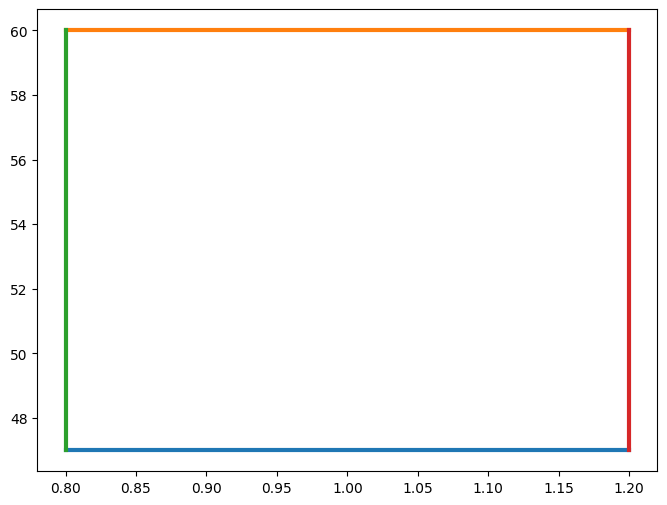

In [14]:
plt.figure(figsize=(8, 6))

x = 1

# Box
plt.plot(
    [x - 0.2, x + 0.2],
    [q1, q1],
    linewidth=3
)

plt.plot(
    [x - 0.2, x + 0.2],
    [q3, q3],
    linewidth=3
)

plt.plot(
    [x - 0.2, x - 0.2],
    [q1, q3],
    linewidth=3
)

plt.plot(
    [x + 0.2, x + 0.2],
    [q1, q3],
    linewidth=3
)

# Median draw

In [15]:
median = calculate_quartile(
    values,
    50
)

print("Median:", median)

Median: 54.0


# Whiskers draw

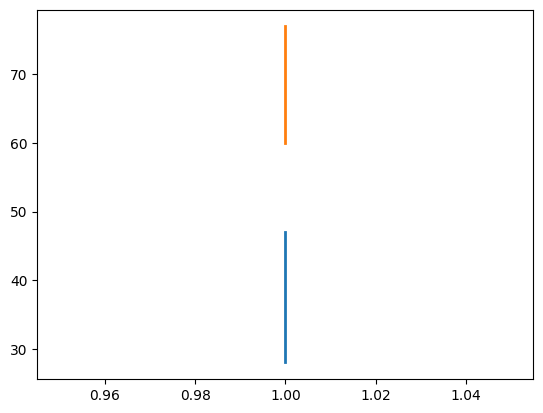

In [16]:
plt.plot(
    [x, x],
    [lower_whisker, q1],
    linewidth=2
)

plt.plot(
    [x, x],
    [q3, upper_whisker],
    linewidth=2
)

# Outliers plot

In [17]:
for value in outliers:

    plt.scatter(
        x,
        value,
        marker="o"
    )

# Final Box Plot

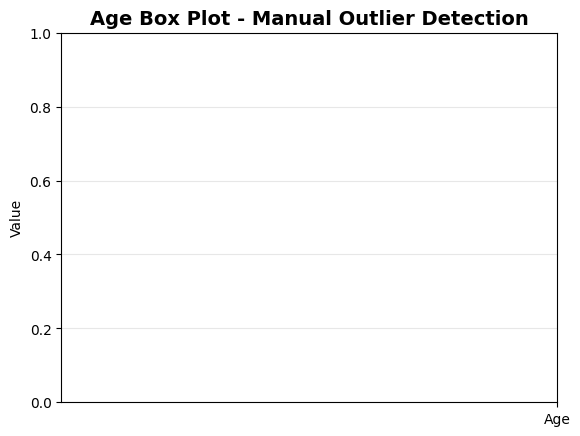

In [18]:
plt.xticks(
    [1],
    ["Age"]
)

plt.ylabel("Value")

plt.title(
    "Age Box Plot - Manual Outlier Detection",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# automatic manual box plot

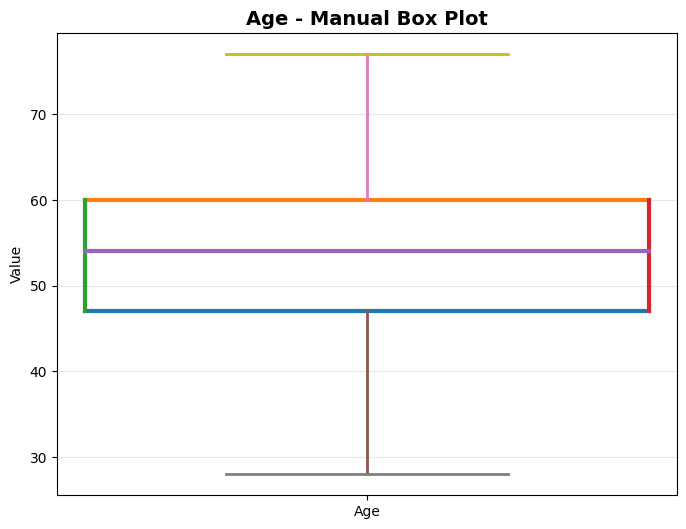

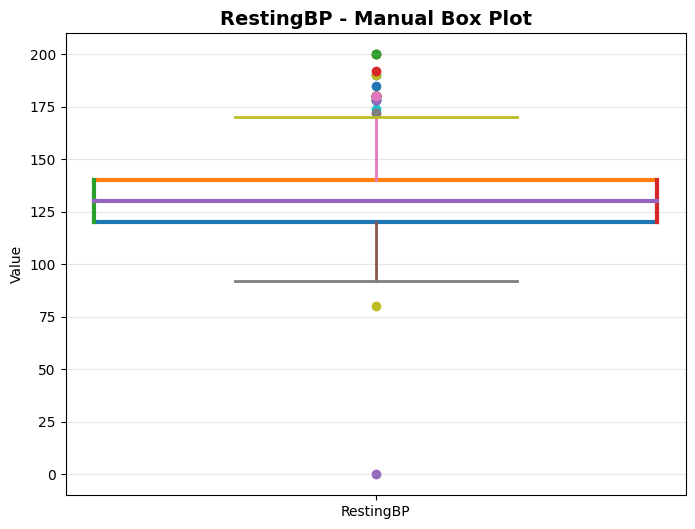

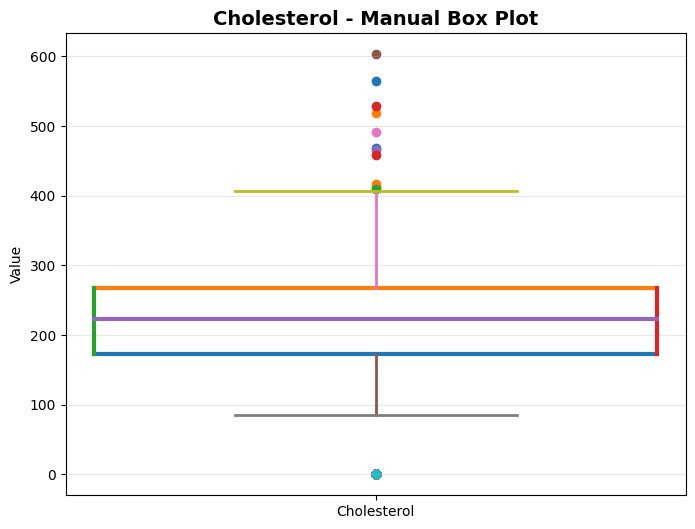

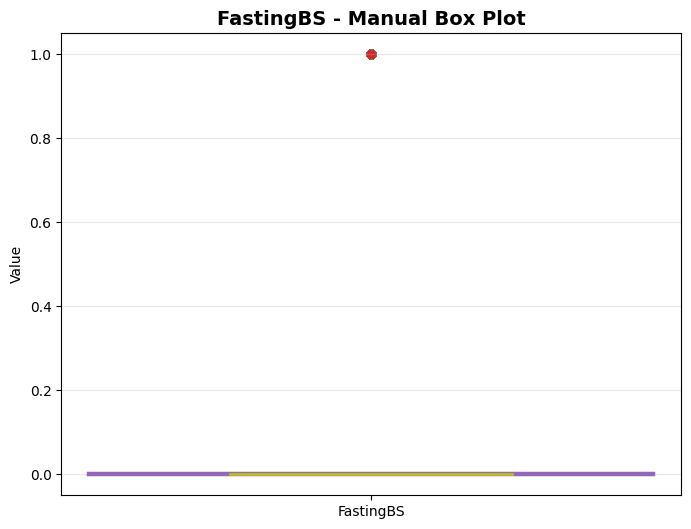

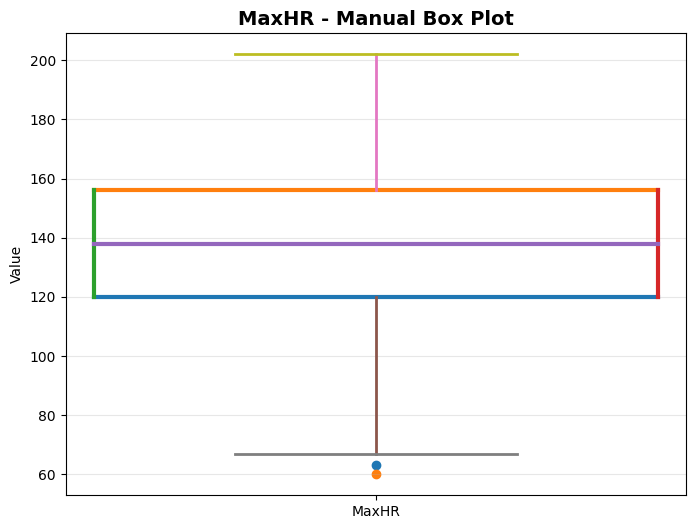

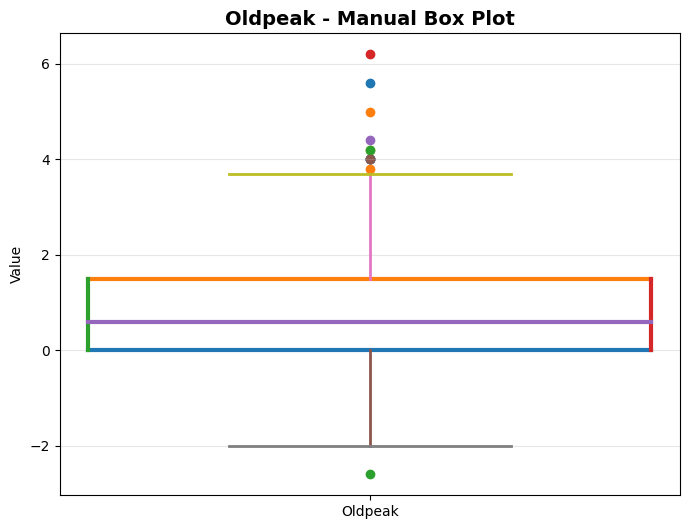

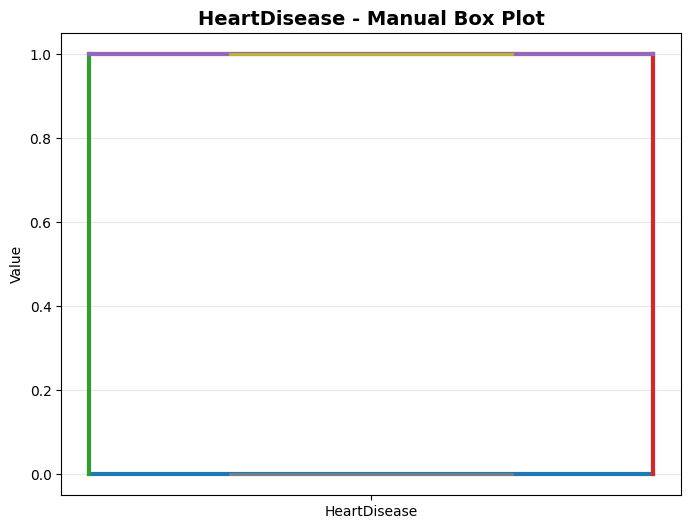

In [19]:
for column in numeric_columns:

    values = numeric_data[column]

    q1 = calculate_quartile(values, 25)
    median = calculate_quartile(values, 50)
    q3 = calculate_quartile(values, 75)

    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    lower_values = []
    upper_values = []
    outliers = []

    for value in values:

        if value >= lower_fence:
            lower_values.append(value)

        if value <= upper_fence:
            upper_values.append(value)

        if (
            value < lower_fence
            or
            value > upper_fence
        ):
            outliers.append(value)

    lower_whisker = min(lower_values)
    upper_whisker = max(upper_values)

    plt.figure(figsize=(8, 6))

    x = 1

    # Box
    plt.plot(
        [x - 0.2, x + 0.2],
        [q1, q1],
        linewidth=3
    )

    plt.plot(
        [x - 0.2, x + 0.2],
        [q3, q3],
        linewidth=3
    )

    plt.plot(
        [x - 0.2, x - 0.2],
        [q1, q3],
        linewidth=3
    )

    plt.plot(
        [x + 0.2, x + 0.2],
        [q1, q3],
        linewidth=3
    )

    # Median
    plt.plot(
        [x - 0.2, x + 0.2],
        [median, median],
        linewidth=3
    )

    # Whiskers
    plt.plot(
        [x, x],
        [lower_whisker, q1],
        linewidth=2
    )

    plt.plot(
        [x, x],
        [q3, upper_whisker],
        linewidth=2
    )

    # Caps
    plt.plot(
        [x - 0.1, x + 0.1],
        [lower_whisker, lower_whisker],
        linewidth=2
    )

    plt.plot(
        [x - 0.1, x + 0.1],
        [upper_whisker, upper_whisker],
        linewidth=2
    )

    # Outliers
    for value in outliers:

        plt.scatter(
            x,
            value,
            marker="o"
        )

    plt.xticks(
        [1],
        [column]
    )

    plt.ylabel("Value")

    plt.title(
        column + " - Manual Box Plot",
        fontsize=14,
        fontweight="bold"
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.show()